# Big Data - Øving 4, Høst 2024
- Student: Jens Christian Aanestad

In [15]:
# Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

### Funksjoner for rensing av data og mer...

In [16]:
# Removes zeros
def clean_remove_zeros(dataframe):
    dataframe.columns = dataframe.columns.str.strip()
    dataframe = dataframe[(dataframe != 0).all(axis=1)]
    return dataframe

# Removes NaN
def clean_remove_nan(dataframe):
    dataframe.columns = dataframe.columns.str.strip()
    dataframe = dataframe.dropna()
    return dataframe

# Replaces NaN with total mean
def clean_replace_nan_with_mean(dataframe):
    dataframe.columns = dataframe.columns.str.strip()
    for i in dataframe.columns:
        if dataframe[i].dtype in ['float64', 'int64']:
            mean_value = dataframe[i].mean(skipna=True)
            dataframe[i] = dataframe[i].fillna(mean_value)
    return dataframe
   
# Replaces NaN with total median
def clean_replace_nan_with_median(dataframe):
    dataframe.columns = dataframe.columns.str.strip()
    for i in dataframe.columns:
        if dataframe[i].dtype in ['float64', 'int64']:
            median_value = dataframe[i].median(skipna=True)
            dataframe[i] = dataframe[i].fillna(median_value)
    return dataframe

# Specially adapted for the life-expectancy-data set
def clean_replace_nan_with_grouped_median(dataframe):
    dataframe.columns = dataframe.columns.str.strip()
    groups = dataframe.groupby('Country')
    for country, group in groups:
        for column in group.columns:
            if group[column].dtype in ['float64', 'int64']:
                median_value = dataframe[column].median(skipna=True)
                if group[column].notna().sum() > 0:
                    median_value = group[column].median(skipna=True)
                dataframe.loc[dataframe['Country'] == country, column] = group[column].fillna(median_value)
    return dataframe

# Specially adapted for the H1 dataset
def clean_replace_zero_adr_with_grouped_mean(dataframe):
    dataframe.columns = dataframe.columns.str.strip()
    groups = dataframe.groupby('Country')
    for country, group in groups:
        group['ADR'] = group['ADR'].apply(lambda x: np.nan if x <= 0 else x)
        mean_value = group['ADR'].mean(skipna=True)
        if pd.isna(mean_value):
            mean_value = dataframe['ADR'].mean(skipna=True)
        filled_values = group['ADR'].fillna(mean_value)
        if dataframe['ADR'].dtype == 'int64':
            filled_values = filled_values.astype(int)
        dataframe.loc[dataframe['Country'] == country, 'ADR'] = filled_values
    return dataframe

# Specially adapted for the H1 dataset
def clean_replace_nan_with_grouped_mean(dataframe, listOfFeatures):
    dataframe.columns = dataframe.columns.str.strip()
    groups = dataframe.groupby('Country')
    for country, group in groups:
        for feature in listOfFeatures:
            mean_value = group[feature].mean(skipna=True)
            if pd.isna(mean_value):
                mean_value = dataframe[feature].mean(skipna=True)
            filled_values = group[feature].fillna(mean_value)
            if dataframe[feature].dtype == 'int64':
                filled_values = filled_values.astype(int)
            dataframe.loc[dataframe['Country'] == country, feature] = filled_values
    return dataframe

# Specially adapted for the ov4-breast-cancer dataset
def clean_replace_question_mark_with_median(dataframe):
    dataframe.columns = dataframe.columns.str.strip()
    for i in dataframe.columns:
        dataframe[i] = dataframe[i].replace('?', np.nan)
        dataframe[i] = pd.to_numeric(dataframe[i], errors='coerce')
        median_value = dataframe[i].median(skipna=True)
        dataframe[i] = dataframe[i].fillna(median_value)
    return dataframe

# Choose k
def choose_k(dataframe):
    k = int(math.sqrt(dataframe.shape[0]))
    if k % 2 == 0:
        k = k + 1
    return k


### Rensing av life-expectancy-data.csv

In [17]:
"""
Life expectancy - Renser ved å erstatte NaN verdier med median
"""
df_life_expectancy = pd.read_csv('life-expectancy-data.csv')
df_life_expectancy = clean_replace_nan_with_grouped_median(df_life_expectancy.copy())
df_life_expectancy


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


### Oppgave 1


In [18]:
# Interesting columns and target (X and y)
columns = ['Alcohol', 'percentage expenditure', 'BMI', 'Schooling', 'GDP']
target = 'Life expectancy'

# Initialize dictionary to store R-squared scores, mean squared error, absolute squared error and intercept
r2_scores = {}
mse_dictionary = {}
mae_dictionary = {}
intercept_dictionary = {}

# Iterate over the selected columns to fit a linear regression model
for column in columns:
    X = df_life_expectancy[[column]]
    y = df_life_expectancy[target]
    
    # Split the data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initialize and train the linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate the R-squared score
    r2 = r2_score(y_test, y_pred)
    r2_scores[column] = r2
    
    # Calculate the mean square error
    mse = mean_squared_error(y_test, y_pred)
    mse_dictionary[column] = mse
    
    # Calculate mean absolute error 
    mae = mean_absolute_error(y_test, y_pred)
    mae_dictionary[column] = mae
    
    intercept = model.intercept_
    intercept_dictionary[column] = intercept
    

# Find the column with the highest R-squared score and lowest mean squared error, and mean absolute error
best_r2_predictor = max(r2_scores, key=r2_scores.get)
best_mse_predictor = min(mse_dictionary, key=mse_dictionary.get)
best_mae_predictor = min(mae_dictionary, key=mae_dictionary.get)

best_r2_score = r2_scores[best_r2_predictor]
best_mse_score = mse_dictionary[best_mse_predictor]
best_mae_score = mae_dictionary[best_mae_predictor]

# Display R-squared scores for all columns
print("R-squared scores:")
for col, score in r2_scores.items():
    print(f"\tR-squared for {col}: {score:.4f}")

# Display mean square error for all columns
print("\n Mean squared errors:")
for col, error in mse_dictionary.items():
    print(f"\tMean squared error for {col}: {error:.4f}")

# Display mean absolute values for all columns
print("\n Mean absolute errors:")
for col, error in mae_dictionary.items():
    print(f"\tMean absolute error for {col}: {error:.4f}")


# Display the results
print(f"\nThe best predictor of Life Expectancy based on R2 scores is '{best_r2_predictor}' with an R-squared score of {best_r2_score:.4f}")
print(f"The best predictor of LIfe Expectancy based on mean squared error is '{best_mse_predictor}' with an mean square error of {best_mse_score:.4f}' ")
print(f"The best predictor of LIfe Expectancy based on mean absolute error is '{best_mae_predictor}' with an mean absolute error of {best_mae_score:.4f}' ")

R-squared scores:
	R-squared for Alcohol: 0.1856
	R-squared for percentage expenditure: 0.1680
	R-squared for BMI: 0.3249
	R-squared for Schooling: 0.5411
	R-squared for GDP: 0.2193

 Mean squared errors:
	Mean squared error for Alcohol: 70.5804
	Mean squared error for percentage expenditure: 72.1029
	Mean squared error for BMI: 58.5065
	Mean squared error for Schooling: 39.7696
	Mean squared error for GDP: 67.6627

 Mean absolute errors:
	Mean absolute error for Alcohol: 6.7052
	Mean absolute error for percentage expenditure: 6.8557
	Mean absolute error for BMI: 5.8540
	Mean absolute error for Schooling: 4.5928
	Mean absolute error for GDP: 6.6002

The best predictor of Life Expectancy based on R2 scores is 'Schooling' with an R-squared score of 0.5411
The best predictor of LIfe Expectancy based on mean squared error is 'Schooling' with an mean square error of 39.7696' 
The best predictor of LIfe Expectancy based on mean absolute error is 'Schooling' with an mean absolute error of 4.5

### Oppgave 2

In [37]:
# Retrieves a list of all countries subsets
countries = df_life_expectancy['Country'].unique()

# Dictionary for life expectancies in 2020
life_expectancy_2020 = {}

# Iterate over each country and fit a linear regression model
for country in countries:
    country_data = df_life_expectancy[df_life_expectancy['Country'] == country]

    # Ensure we have enough data to build a model
    if len(country_data) < 2:
        continue
    
    X = country_data[['Year']]
    y = country_data['Life expectancy']
    
    # Split the data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
        
    # Make predictions for the year 2020
    predicted_life_expectancy = model.predict(pd.DataFrame([[2020]], columns=['Year']))[0]
    # predicted_life_expectancy = model.predict([[2020]])

    # Store the prediction for this country
    life_expectancy_2020[country] = predicted_life_expectancy

# Convert the dictionary to a pandas Series
life_expectancy_2020_series = pd.Series(life_expectancy_2020)

# Find the country with the highest predicted life expectancy for 2020
best_country = life_expectancy_2020_series.idxmax()
best_life_expectancy = life_expectancy_2020_series.max()

# Display the result
print(f"The country predicted with best life expectancy in 2020 is '{best_country}' with a life expectancy of {best_life_expectancy:.2f} years.")

# Display the top 10 countries with the highest life expectancy
top_10_countries = life_expectancy_2020_series.nlargest(10)
print("\nTop 10 countries with the highest predicted life expectancy in 2020:")
top_10_countries


The country predicted with best life expectancy in 2020 is 'United Kingdom of Great Britain and Northern Ireland' with a life expectancy of 90.88 years.

Top 10 countries with the highest predicted life expectancy in 2020:


United Kingdom of Great Britain and Northern Ireland    90.882220
Austria                                                 90.236282
Germany                                                 89.583484
Finland                                                 88.545668
Greece                                                  88.251986
Belgium                                                 88.105776
Portugal                                                87.749729
Ireland                                                 86.955957
Republic of Korea                                       86.931588
Luxembourg                                              86.890975
dtype: float64

### Rensing av H1.csv

In [20]:
"""
H1 - Renser ved å erstatte NaN
"""
df_h1 = pd.read_csv('H1.csv')
features = ['ADR', 'BookingChanges', 'PreviousCancellations', 'PreviousBookingsNotCanceled',
            'Adults', 'Children', 'Babies', 'IsRepeatedGuest', 'RequiredCarParkingSpaces', 'TotalOfSpecialRequests']
df_h1 = clean_replace_zero_adr_with_grouped_mean(df_h1)
df_h1 = clean_replace_nan_with_grouped_mean(df_h1, features)

df_h1[features]

,ADR,BookingChanges,PreviousCancellations,PreviousBookingsNotCanceled,Adults,Children,Babies,IsRepeatedGuest,RequiredCarParkingSpaces,TotalOfSpecialRequests
0,95.166182,3,0,0,2,0,0,0,0,0
1,95.166182,4,0,0,2,0,0,0,0,0
2,75.000000,0,0,0,1,0,0,0,0,0
3,75.000000,0,0,0,1,0,0,0,0,0
4,98.000000,0,0,0,2,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
40055,89.750000,1,0,0,2,1,0,0,0,0
40056,202.270000,0,0,0,2,0,0,0,0,1
40057,153.570000,0,0,0,2,0,0,0,0,3
40058,112.800000,0,0,0,2,0,0,0,0,1


### Oppgave 3

In [21]:
# Define the features and target
features = ['ADR', 'BookingChanges', 'PreviousCancellations', 'PreviousBookingsNotCanceled',
            'Adults', 'Children', 'Babies', 'IsRepeatedGuest', 'RequiredCarParkingSpaces', 'TotalOfSpecialRequests']
target = 'IsCanceled'

# Select the features and target from the dataset
X = df_h1[features]
y = df_h1[target]

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Choosing k by square root of y_test
k = choose_k(y_test)

# Initialize and training the KNN classifier
knn = KNeighborsClassifier(k)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Print k
print(f"k: {k}")

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Print the confusion matrix
c_m = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(c_m)

# True Positive Rate
true_positive_rate = c_m[0][0] / (c_m[0][0] + c_m[1][0])

# True Negative Rate
true_negative_rate = c_m[1][1] / (c_m[1][1] + c_m[0][1])

# Accuracy
accuracy = (c_m[1][1] + c_m[0][0]) / (c_m[1][1] + c_m[1][0] + c_m[0][1] + c_m[0][0])

print(f"\nTrue positive rate: {true_positive_rate:.2f}")
print(f"True negative rate: {true_negative_rate:.2f}")
print(f"Accuracy: {accuracy:.2f}")

k: 89

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85      5798
           1       0.64      0.33      0.44      2214

    accuracy                           0.76      8012
   macro avg       0.71      0.63      0.64      8012
weighted avg       0.74      0.76      0.74      8012

Confusion Matrix:
[[5383  415]
 [1482  732]]

True positive rate: 0.78
True negative rate: 0.64
Accuracy: 0.76


### Resning av ov4-breast-cancer.csv

In [22]:
"""
ov4-breast-cancer - Renser ved å erstatte NaN med median
"""
df_breast_cancer = pd.read_csv('ov4-breast-cancer.csv')
df_breast_cancer = clean_replace_question_mark_with_median(df_breast_cancer)
df_breast_cancer

,id,clump_thickness,unif_cell_size,unif_cell_shape,marg_adhesion,single_epith_cell_size,bare_nuclei,bland_chrom,norm_nucleoli,mitoses,classes
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,0
695,841769,2,1,1,1,2,1.0,1,1,1,0
696,888820,5,10,10,3,7,3.0,8,10,2,1
697,897471,4,8,6,4,3,4.0,10,6,1,1


### Oppgave 4
- Med normalisering

In [23]:
# Select the features and target from the dataset
X = df_breast_cancer.drop('classes', axis=1)
y = df_breast_cancer['classes']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Choosing k by square root of y_test
k = choose_k(y_test)

# Initialize and training the KNN classifier
knn = KNeighborsClassifier(k)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

print(f"k: {k}")

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Print the confusion matrix
c_m = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(c_m)

# True Positive Rate
true_positive_rate = c_m[0][0] / (c_m[0][0] + c_m[1][0])

# True Negative Rate
true_negative_rate = c_m[1][1] / (c_m[1][1] + c_m[0][1])

# Accuracy
accuracy = (c_m[1][1] + c_m[0][0]) / (c_m[1][1] + c_m[1][0] + c_m[0][1] + c_m[0][0])

print(f"\nTrue positive rate: {true_positive_rate:.2f}")
print(f"True negative rate: {true_negative_rate:.2f}")
print(f"Accuracy: {accuracy:.2f}")


k: 11

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98        95
           1       0.98      0.96      0.97        45

    accuracy                           0.98       140
   macro avg       0.98      0.97      0.98       140
weighted avg       0.98      0.98      0.98       140

Confusion Matrix:
[[94  1]
 [ 2 43]]

True positive rate: 0.98
True negative rate: 0.98
Accuracy: 0.98


### Oppgave 4
- Uten normalisering

In [24]:
# Select the features and target from the dataset
X = df_breast_cancer.drop('classes', axis=1)
y = df_breast_cancer['classes']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choosing k by square root of y_test
k = choose_k(y_test)

# Initialize and training the KNN classifier
knn = KNeighborsClassifier(k)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Print k
print(f"k: {k}")

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Print the confusion matrix
c_m = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(c_m)

# True Positive Rate
true_positive_rate = c_m[0][0] / (c_m[0][0] + c_m[1][0])

# True Negative Rate
true_negative_rate = c_m[1][1] / (c_m[1][1] + c_m[0][1])

# Accuracy
accuracy = (c_m[1][1] + c_m[0][0]) / (c_m[1][1] + c_m[1][0] + c_m[0][1] + c_m[0][0])

print(f"\nTrue positive rate: {true_positive_rate:.2f}")
print(f"True negative rate: {true_negative_rate:.2f}")
print(f"Accuracy: {accuracy:.2f}")


k: 11

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.87      0.79        95
           1       0.52      0.29      0.37        45

    accuracy                           0.69       140
   macro avg       0.62      0.58      0.58       140
weighted avg       0.66      0.69      0.66       140

Confusion Matrix:
[[83 12]
 [32 13]]

True positive rate: 0.72
True negative rate: 0.52
Accuracy: 0.69


### Plotter accuracy for forskjellige K-verdier (med normalisering)

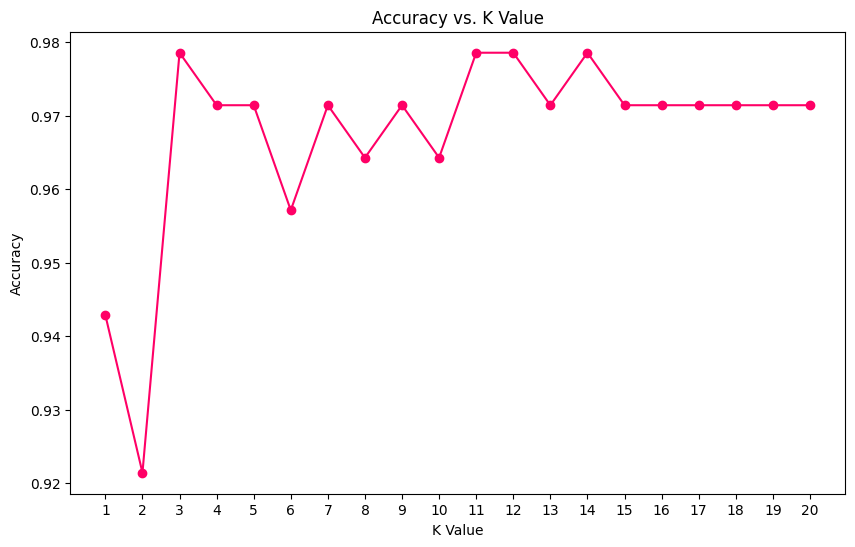

Top 5 k values with the highest accuracies:
k = 3, Accuracy = 0.9786
k = 11, Accuracy = 0.9786
k = 12, Accuracy = 0.9786
k = 14, Accuracy = 0.9786
k = 4, Accuracy = 0.9714

Top 5 k confusion matrices
k = 3, Confusion matrix:
[[94  1]
 [ 2 43]]
k = 11, Confusion matrix:
[[94  1]
 [ 2 43]]
k = 12, Confusion matrix:
[[94  1]
 [ 2 43]]
k = 14, Confusion matrix:
[[94  1]
 [ 2 43]]
k = 4, Confusion matrix:
[[94  1]
 [ 3 42]]


In [25]:
# Select the features and target from the dataset
X = df_breast_cancer.drop('classes', axis=1)
y = df_breast_cancer['classes']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# List to store accuracy values for each k
accuracies = []
# List to store confusion matrices
confusion_matrices = []

# Test for k values from 1 to 20
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    c_m = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(c_m)

# Plot the accuracies vs. k values
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), accuracies, marker='o', linestyle='-', color='#ff0066')
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, 21, step=1))
plt.show()

# Combine k values and their corresponding accuracies
k_accuracy_pairs = list(zip(range(1, 21), accuracies))

# Sort by accuracy in descending order and select the top 5
top_5_k = sorted(k_accuracy_pairs, key=lambda x: x[1], reverse=True)[:5]

# Print the top 5 k values with the highest accuracies
print("Top 5 k values with the highest accuracies:")
for k, acc in top_5_k:
    print(f"k = {k}, Accuracy = {acc:.4f}")
    
print(f"\nTop 5 k confusion matrices")
for k, acc in top_5_k:
    print(f"k = {k}, Confusion matrix:")
    print(confusion_matrices[k-1])


### Korreksjon av oppgave 2

In [30]:
###########################
# OPPGAVE 2               #
###########################

# Implement a solution which shows which country is likely to have the best life expectancy in 2020
#

df = pd.read_csv("life-expectancy-data.csv")
countries = pd.unique(df['Country'])
max_age = 0
max_country = ''
for country in countries:
    df_filtered = df[df['Country'] == country]

    df_filtered = df_filtered.dropna(subset=['Life expectancy ', 'Year'], how='any')

    if len(df_filtered) == 0:
        continue
    X = df_filtered['Year']
    y = df_filtered['Life expectancy ']

    # Need to reshape to make fit() happy
    X = np.array(X).reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)

    # Split into training and test subsets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

    # Train the model
    regressor = LinearRegression()
    regressor.fit(X_train, y_train)

    # Predict prices from our testing set containing number of rooms
    predicted_life_expectancy_in_2020 = regressor.predict([[2020]])
    if predicted_life_expectancy_in_2020> max_age: # We save the highest life expectancy so far (along with the country)
        max_age = predicted_life_expectancy_in_2020
        max_country = country

    # print(f"Predicted life expectancy in 2020 for {country}: {predicted_life_expectancy_in_2020}")

print(f"Country with expected highest life expectancy 2020 i {max_country} with {max_age} years.")


Country with expected highest life expectancy 2020 i Slovenia with [[89.91464165]] years.
